<a href="https://colab.research.google.com/github/scudilio/FIAP_MBA-Feature_Engineering/blob/main/aula_3_mba_feature_engineering_reducao_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redução de Dimensão em Imagens: PCA (com reconstrução) + Autoencoder (conceito)

Este notebook usa **uma imagem real (PNG)** fornecida por você e demonstra:

1. **Como aplicar PCA em uma imagem** (tratando a imagem como dados numéricos).
2. **Como a escolha do número de componentes (k)** afeta a **reconstrução** (qualidade vs compressão).
3. Uma explicação clara sobre **Autoencoders** e **outra técnica** simples de redução de dimensão (downsampling).

> **Imagem usada no projeto:** `Gemini_Generated_Image_r88a0qr88a0qr88a.png`  
> Caminho no ambiente: `/mnt/data/Gemini_Generated_Image_r88a0qr88a0qr88a.png`

## 1) Setup e leitura da imagem

Vamos carregar a imagem e convertê-la para:

- **RGB** (3 canais) para visualizar.
- **Grayscale** (1 canal) para facilitar o PCA (pode ser feito em RGB também, mas a demo fica mais direta).

### Por que converter para grayscale?
PCA trabalha melhor quando você define claramente o vetor de features.  
No caso de uma imagem RGB, você teria 3 valores por pixel (R, G, B).  
Em grayscale, fica **1 valor por pixel**, o que simplifica a interpretação.

> Observação: Mais abaixo eu deixo um modo opcional de fazer PCA por canal (RGB).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
img_path = "/content/Gemini_Generated_Image_r88a0qr88a0qr88a.png"


In [ ]:
# Carrega imagem
img_rgb = Image.open(img_path).convert("RGB")
img_gray = img_rgb.convert("L")  # grayscale

RGB shape: (1024, 1024, 3)
Gray shape: (1024, 1024)


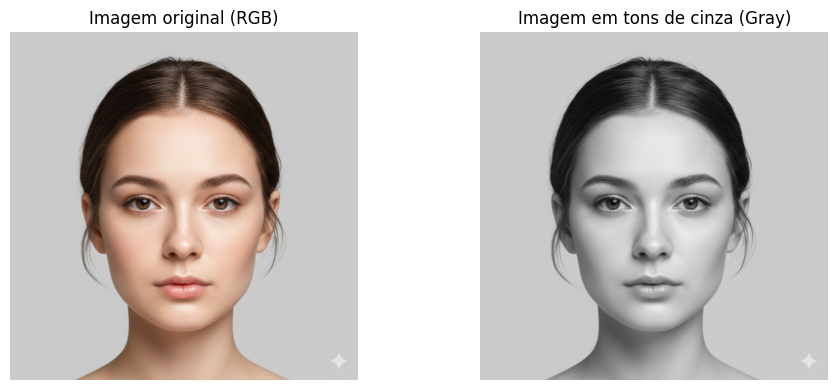

In [ ]:


# Carrega imagem
img_rgb = Image.open(img_path).convert("RGB")
img_gray = img_rgb.convert("L")  # grayscale

# Converte para arrays [0,1]
X_rgb = np.asarray(img_rgb).astype(np.float32) / 255.0     # (H,W,3)
X_gray = np.asarray(img_gray).astype(np.float32) / 255.0   # (H,W)

H, W = X_gray.shape

print("RGB shape:", X_rgb.shape)
print("Gray shape:", X_gray.shape)

# Visualização
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(X_rgb)
plt.title("Imagem original (RGB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_gray, cmap="gray", vmin=0, vmax=1)
plt.title("Imagem em tons de cinza (Gray)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_gray

array([[0.7921569 , 0.79607844, 0.7921569 , ..., 0.7882353 , 0.8039216 ,
        0.80784315],
       [0.7921569 , 0.79607844, 0.7882353 , ..., 0.7921569 , 0.7921569 ,
        0.8       ],
       [0.79607844, 0.7921569 , 0.7921569 , ..., 0.79607844, 0.79607844,
        0.79607844],
       ...,
       [0.79607844, 0.79607844, 0.79607844, ..., 0.8       , 0.79607844,
        0.79607844],
       [0.79607844, 0.79607844, 0.8       , ..., 0.79607844, 0.7921569 ,
        0.79607844],
       [0.8       , 0.79607844, 0.8       , ..., 0.7921569 , 0.79607844,
        0.7921569 ]], dtype=float32)

## 2) Como aplicar PCA em uma imagem (jeito simples e interpretável)

Existem várias formas de aplicar PCA em imagens. Duas abordagens comuns:

### Abordagem A — PCA considerando as **linhas** como amostras
- Cada linha da imagem tem `W` pixels ⇒ vira um vetor de dimensão `W`.
- Então temos `H` amostras (uma por linha).
- O PCA aprende padrões ao longo da **largura** da imagem.

**Vantagens**
- Implementação simples.
- Dá para reconstruir a imagem com `inverse_transform`.
- A escolha do `k` (componentes) controla diretamente a fidelidade.

**Limitação**
- Você está “modelando” a imagem como um conjunto de linhas; é uma simplificação didática, mas funciona muito bem para demonstrar PCA.

> É essa abordagem que vamos usar para comparar diferentes valores de `k`.

In [ ]:
from sklearn.decomposition import PCA

# Matriz para PCA (Amostras = linhas, Features = pixels por linha)
X = X_gray  # shape (H, W)

def pca_reconstruct_image(X_lines, k):
    """Treina PCA nas linhas (H amostras, W features) e reconstrói a imagem."""
    pca = PCA(n_components=k, random_state=42)
    Z = pca.fit_transform(X_lines)          # compressão: (H, k)
    X_hat = pca.inverse_transform(Z)        # reconstrução: (H, W)
    explained = pca.explained_variance_ratio_.sum()
    return X_hat, explained, pca

# Diferentes quantidades de componentes para comparar
k_list = [5, 10, 20, 40, 80, min(W, 160)]
k_list = [k for k in k_list if k <= W]

recons = []
info = []

for k in k_list:
    X_hat, explained, _ = pca_reconstruct_image(X, k)
    recons.append(X_hat)
    info.append((k, explained))

info

[(5, np.float32(0.90033424)),
 (10, np.float32(0.95066)),
 (20, np.float32(0.9766762)),
 (40, np.float32(0.9884723)),
 (80, np.float32(0.9946252)),
 (160, np.float32(0.9980084))]

## 3) Comparando reconstruções: poucos vs muitos componentes

Interpretação:

- **k pequeno**: compressão alta ⇒ a reconstrução tende a ficar mais “suave” e perder detalhes finos.
- **k grande**: compressão menor ⇒ a reconstrução preserva mais textura e bordas.

Além disso, mostramos a **variância explicada acumulada** pelo PCA (aprox. “quanta informação do dado” está sendo capturada).

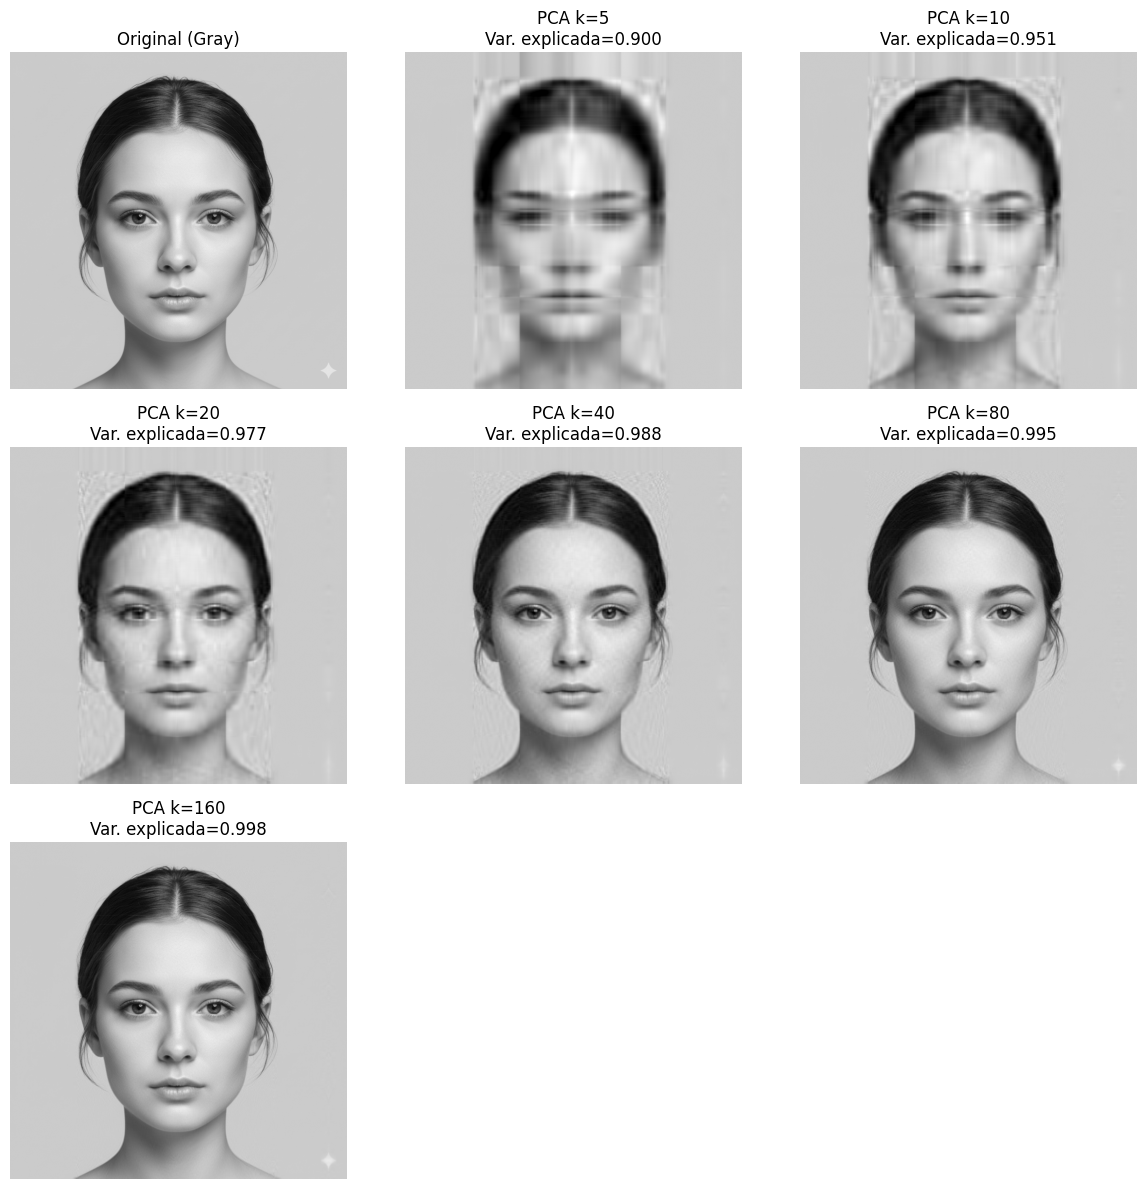

In [ ]:
# Plot: original + reconstruções
n = 1 + len(k_list)
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(12, 4*rows))

# Original
plt.subplot(rows, cols, 1)
plt.imshow(X_gray, cmap="gray", vmin=0, vmax=1)
plt.title("Original (Gray)")
plt.axis("off")

for i, (X_hat, (k, explained)) in enumerate(zip(recons, info), start=2):
    plt.subplot(rows, cols, i)
    X_hat_clipped = np.clip(X_hat, 0, 1)
    plt.imshow(X_hat_clipped, cmap="gray", vmin=0, vmax=1)
    plt.title(f"PCA k={k}\nVar. explicada={explained:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4) Curva de variância explicada acumulada (para escolher k)

Um jeito prático de escolher `k` é:

- Calcular a **variância explicada acumulada**
- Escolher o menor `k` que atinge um patamar (ex.: 0.90 ou 0.95)

**Importante:** não existe um “k perfeito” universal — depende do objetivo:
- Se você quer compressão agressiva, usa `k` menor.
- Se você quer reconstrução mais fiel, usa `k` maior.

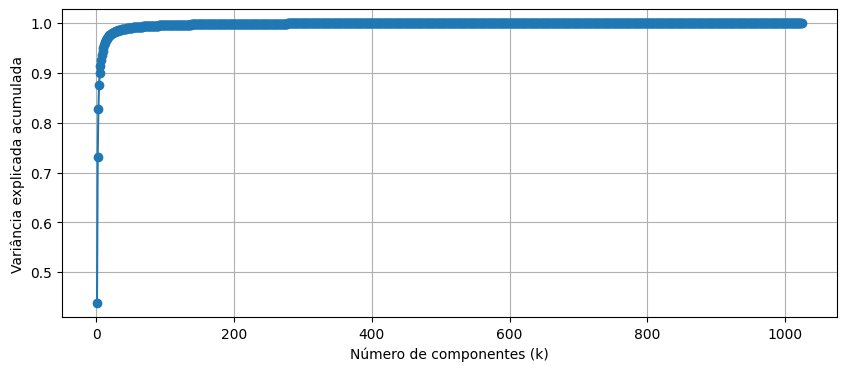

Menor k para >= 90%: 5
Menor k para >= 95%: 10


In [ ]:
# PCA máximo possível (para obter a curva completa)
pca_full = PCA(n_components=min(H, W), random_state=42)
pca_full.fit(X)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("Variância explicada acumulada")
plt.grid(True)
plt.show()

k90 = int(np.argmax(cum_var >= 0.90) + 1)
k95 = int(np.argmax(cum_var >= 0.95) + 1)
print("Menor k para >= 90%:", k90)
print("Menor k para >= 95%:", k95)

## 5) (Opcional) PCA em RGB: por canal

Uma alternativa “simples e honesta” para imagens coloridas é aplicar PCA **separadamente em cada canal**:

- PCA no canal **R**
- PCA no canal **G**
- PCA no canal **B**

Depois, você junta os canais reconstruídos e obtém uma imagem RGB reconstruída.

**Vantagem:** mantém a simplicidade do PCA em 2D.  
**Limitação:** ignora correlação entre canais (padrões que envolvem mistura de cores).

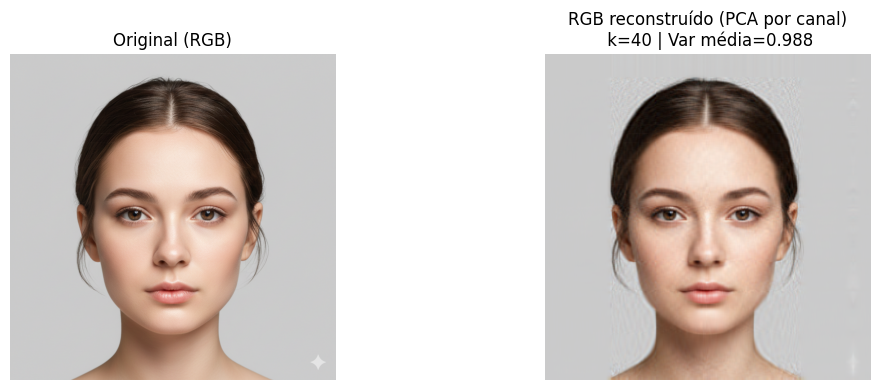

In [ ]:
def pca_reconstruct_rgb_by_channel(X_rgb, k):
    X_hat = np.zeros_like(X_rgb)
    explained_sum = 0.0
    for c in range(3):
        Xc = X_rgb[:, :, c]
        Xc_hat, explained, _ = pca_reconstruct_image(Xc, k)
        X_hat[:, :, c] = np.clip(Xc_hat, 0, 1)
        explained_sum += explained
    explained_mean = explained_sum / 3.0
    return X_hat, explained_mean

k_rgb = min(40, W)  # ajuste se quiser
X_rgb_hat, explained_mean = pca_reconstruct_rgb_by_channel(X_rgb, k_rgb)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(X_rgb)
plt.title("Original (RGB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_rgb_hat)
plt.title(f"RGB reconstruído (PCA por canal)\n k={k_rgb} | Var média={explained_mean:.3f}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 6) Autoencoders (explicação) — outra forma de reduzir dimensão

Um **autoencoder** é uma rede neural que aprende:

- **Encoder**: comprime a entrada para um vetor pequeno (**representação latente**).
- **Decoder**: reconstrói a entrada a partir desse vetor.

### Por que isso é “redução de dimensionalidade”?
Porque você força um gargalo:
- Imagem (muitos pixels) → **latente (poucos números)** → reconstrução.

### PCA vs Autoencoder (resumo)
- **PCA**: compressão **linear**; rápido e interpretável.
- **Autoencoder**: compressão **não-linear**; captura padrões mais complexos (bordas, texturas, etc.).

> Na prática, para imagens, é comum usar **Convolutional Autoencoders**.

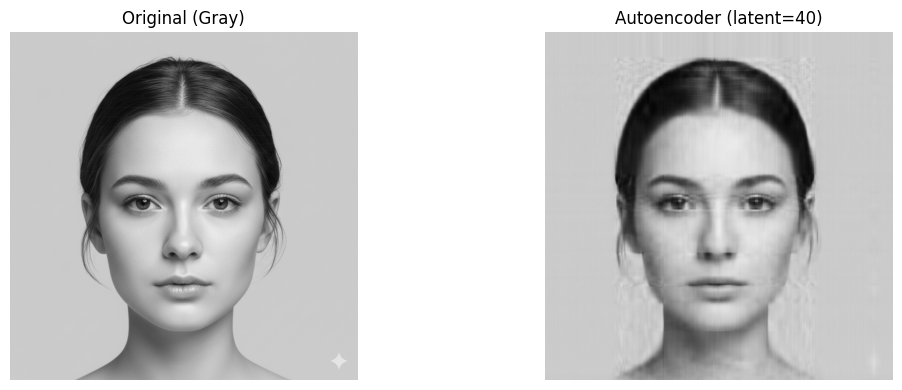

In [ ]:
# (Opcional) Exemplo DIDÁTICO de autoencoder denso em linhas (requer tensorflow).
# Se você não tiver tensorflow instalado, pode pular essa célula.

# Descomente para rodar:
import tensorflow as tf
from tensorflow.keras import layers, Model

X_lines = X_gray.astype("float32")  # (H, W)
latent_dim = min(40, W)  # dimensão reduzida

inp = layers.Input(shape=(W,))
x = layers.Dense(128, activation="relu")(inp)
z = layers.Dense(latent_dim, activation="linear")(x)  # gargalo
x = layers.Dense(128, activation="relu")(z)
out = layers.Dense(W, activation="sigmoid")(x)

ae = Model(inp, out)
ae.compile(optimizer="adam", loss="mse")
ae.fit(X_lines, X_lines, epochs=80, batch_size=32, verbose=0)

X_hat = ae.predict(X_lines, verbose=0)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(X_gray, cmap="gray", vmin=0, vmax=1); plt.title("Original (Gray)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(np.clip(X_hat,0,1), cmap="gray", vmin=0, vmax=1); plt.title(f"Autoencoder (latent={latent_dim})"); plt.axis("off")
plt.tight_layout(); plt.show()

## 7) Outra técnica simples: Downsampling (resize)

Reduzir a resolução (H×W → h×w) também reduz dimensionalidade (menos pixels).

**Vantagens:** simples, rápido, sem treino.  
**Desvantagens:** perde detalhe diretamente.

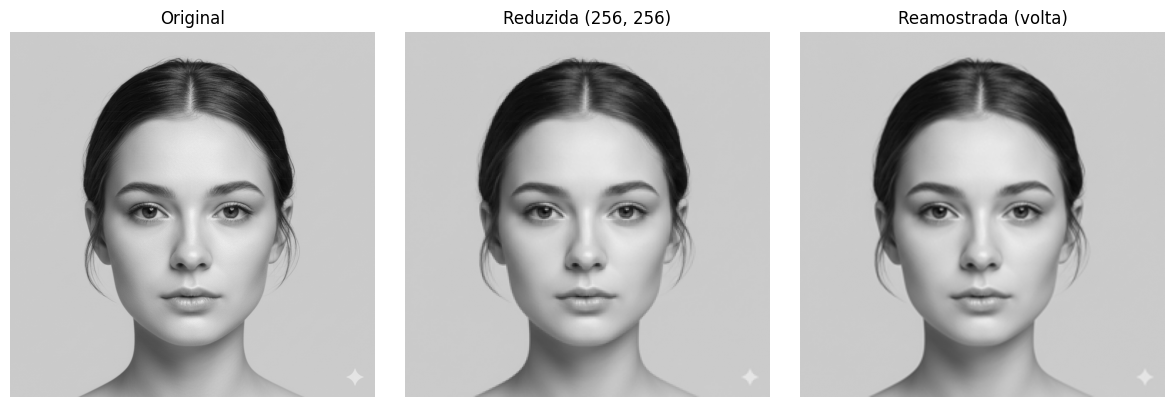

In [ ]:
# Downsampling + volta para o tamanho original (para comparar visualmente)
scale = 4  # quanto reduzir (4 = 1/4 em cada dimensão)

new_size = (W//scale, H//scale)
img_small = img_gray.resize(new_size)
img_back = img_small.resize((W, H))

X_small = np.asarray(img_small).astype(np.float32) / 255.0
X_back = np.asarray(img_back).astype(np.float32) / 255.0

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(X_gray, cmap="gray", vmin=0, vmax=1); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(X_small, cmap="gray", vmin=0, vmax=1); plt.title(f"Reduzida {new_size}"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(X_back, cmap="gray", vmin=0, vmax=1); plt.title("Reamostrada (volta)"); plt.axis("off")
plt.tight_layout()
plt.show()